In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset,random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
assert torch.cuda.is_available(), "CUDA NOT AVAILABLE — GPU CANNOT BE USED"

device = torch.device("cuda:1")   # use GPU 0
print("Using GPU:", torch.cuda.get_device_name(1))

Using GPU: NVIDIA L4


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

trainset = datasets.CIFAR10(
    root="/DATA/suraj/pr1/datasets",
    train=True,
    download=True,
    transform=transform
)

testset = datasets.CIFAR10(
    root="/DATA/suraj/pr1/datasets",
    train=False,
    download=True,
    transform=transform
)

In [5]:
x_train, x_test = train_test_split(
    trainset, test_size=0.2, random_state=42, shuffle=True
)

In [6]:

train_loader = DataLoader(x_train, batch_size=128, shuffle=True)
val_loader = DataLoader(x_test, batch_size=128)
test_loader = DataLoader(testset, batch_size=128)


In [7]:
model = models.resnet18(weights=None)
# 2. Adjust for CIFAR-10
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 10)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []

num_epochs = 10

for epoch in range(num_epochs):
    # -------- TRAIN --------
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # -------- VALIDATION --------
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss = running_loss / total
    val_acc = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )


Epoch [1/10] | Train Loss: 1.4573, Train Acc: 0.4656 | Val Loss: 1.7063, Val Acc: 0.4454
Epoch [2/10] | Train Loss: 0.9476, Train Acc: 0.6627 | Val Loss: 0.9448, Val Acc: 0.6705
Epoch [3/10] | Train Loss: 0.7168, Train Acc: 0.7454 | Val Loss: 0.9302, Val Acc: 0.6713
Epoch [4/10] | Train Loss: 0.5662, Train Acc: 0.8034 | Val Loss: 0.7156, Val Acc: 0.7567
Epoch [5/10] | Train Loss: 0.4566, Train Acc: 0.8394 | Val Loss: 0.6783, Val Acc: 0.7769
Epoch [6/10] | Train Loss: 0.3696, Train Acc: 0.8717 | Val Loss: 0.6117, Val Acc: 0.8027
Epoch [7/10] | Train Loss: 0.2832, Train Acc: 0.9007 | Val Loss: 0.6063, Val Acc: 0.7989
Epoch [8/10] | Train Loss: 0.2168, Train Acc: 0.9237 | Val Loss: 0.5796, Val Acc: 0.8193
Epoch [9/10] | Train Loss: 0.1555, Train Acc: 0.9470 | Val Loss: 0.8259, Val Acc: 0.7719
Epoch [10/10] | Train Loss: 0.1156, Train Acc: 0.9594 | Val Loss: 1.0108, Val Acc: 0.7599


In [10]:
import os

os.makedirs("checkpoints", exist_ok=True)

MODEL_PATH = "checkpoints/resnet18_cifar10_baseline1.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epoch": num_epochs
}, MODEL_PATH)

print(f"Model saved at {MODEL_PATH}")


Model saved at checkpoints/resnet18_cifar10_baseline1.pth


In [ ]:
MODEL_PATH = "checkpoints/resnet18_cifar10_baseline1.pth"

checkpoint = torch.load(MODEL_PATH, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()  

print("Model loaded successfully")

Model loaded successfully


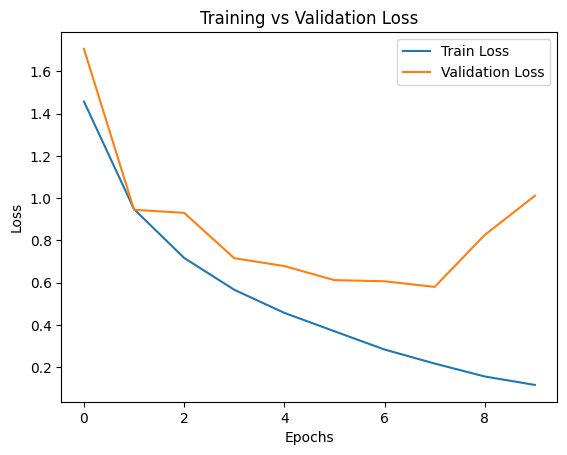

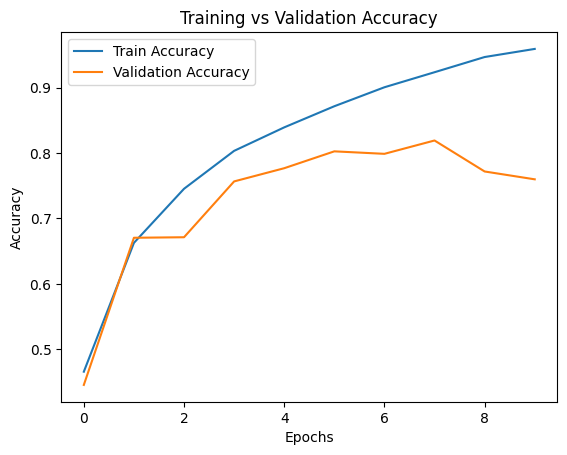

In [12]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


In [13]:
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total
print(f"Final Test Accuracy: {test_accuracy:.4f}")


Final Test Accuracy: 0.7530


In [21]:
classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"]

In [ ]:
import torch.nn.functional as F
import os
from torchvision.utils import save_image

os.makedirs("failure_cases_2", exist_ok=True)

model.eval()
failure_cases = []

with torch.no_grad():
    for idx, (images, labels) in enumerate(test_loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)

        probs = F.softmax(outputs, dim=1)
        confs, preds = torch.max(probs, 1)

        for i in range(images.size(0)):
            if preds[i] != labels[i]:
                failure_cases.append({
                    "image": images[i].cpu(),
                    "true": labels[i].item(),
                    "pred": preds[i].item(),
                    "conf": confs[i].item()
                })

failure_cases = sorted(failure_cases, key=lambda x: x["conf"], reverse=True)

for i, case in enumerate(failure_cases[:20]):
    save_image(case["image"], f"failure_cases_2/failure_{i}.png")

    true_class = classes[case["true"]]
    pred_class = classes[case["pred"]]

    print(
        f"Failure {i}: "
        f"True = {true_class} ({case['true']}), "
        f"Pred = {pred_class} ({case['pred']}), "
        f"Confidence = {case['conf']:.4f}"
    )


Failure 0: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failure 1: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failure 2: True = bird (2), Pred = frog (6), Confidence = 1.0000
Failure 3: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failure 4: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failure 5: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failure 6: True = airplane (0), Pred = truck (9), Confidence = 1.0000
Failure 7: True = cat (3), Pred = frog (6), Confidence = 1.0000
Failure 8: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failure 9: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failure 10: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failure 11: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failure 12: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failure 13: True = automobile (1), Pred = truck (9), Confidence = 1.0000
Failu

In [16]:
torch.save(failure_cases, "failure_cases_baseline_2.pt")

In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2
import os

target_layers = [model.layer4[-1]]
os.makedirs("gradcam_2", exist_ok=True)

model.eval()

cam = GradCAM(
    model=model,
    target_layers=target_layers,
    
)

for i, case in enumerate(failure_cases[:20]):
    input_tensor = case["image"].unsqueeze(0).float().to(device)
    targets = [ClassifierOutputTarget(case["pred"])]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    rgb_img = case["image"].permute(1, 2, 0).cpu().numpy()
    rgb_img = np.clip(rgb_img, 0, 1)

    cam_image = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    cv2.imwrite(
        f"gradcam_2/failure_{i}.png",
        cv2.cvtColor(cam_image, cv2.COLOR_RGB2BGR)
    )

    print(
        f"Grad-CAM saved | "
        f"T={case['true']} P={case['pred']} Conf={case['conf']:.2f}"
    )



Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=2 P=6 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=0 P=9 Conf=1.00
Grad-CAM saved | T=3 P=6 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=3 P=6 Conf=1.00
Grad-CAM saved | T=2 P=6 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00
Grad-CAM saved | T=0 P=9 Conf=1.00
Grad-CAM saved | T=1 P=9 Conf=1.00


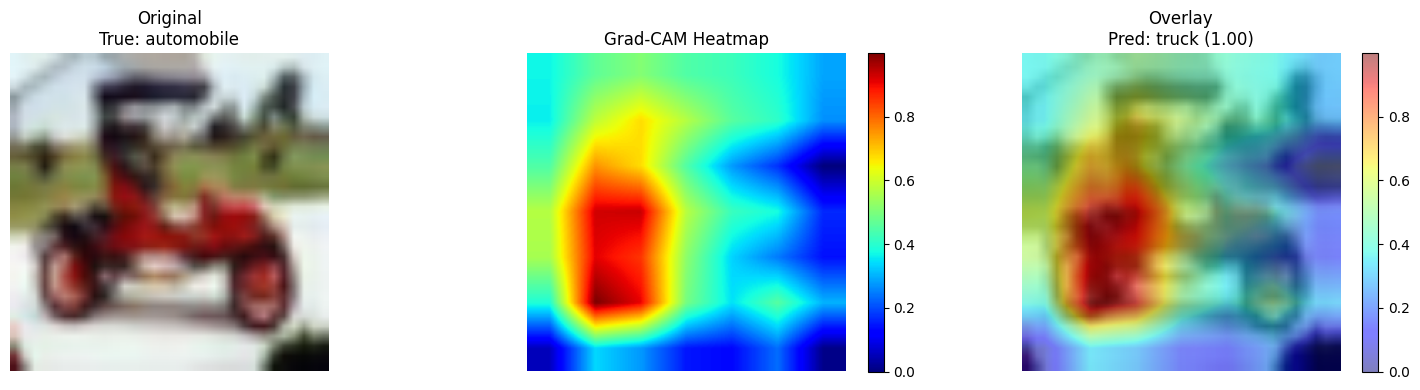

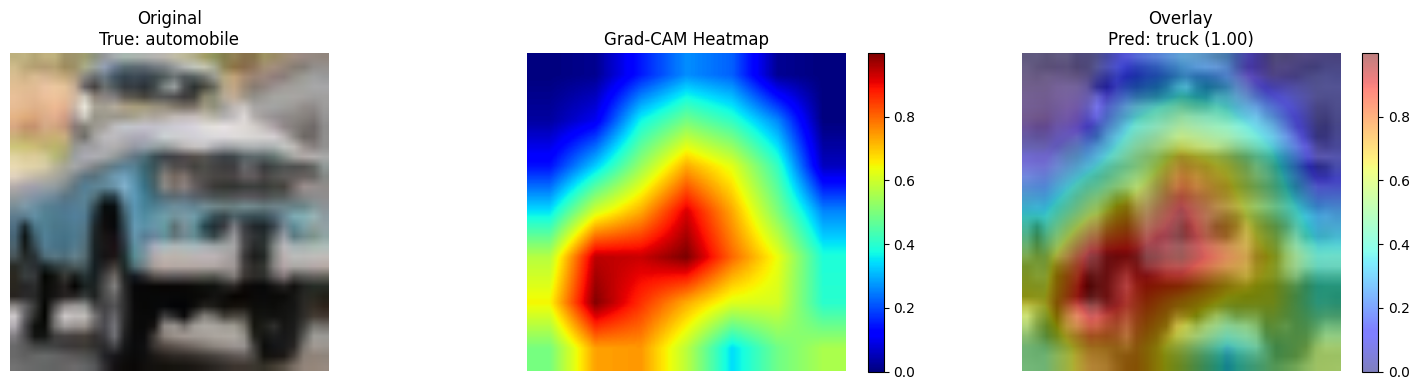

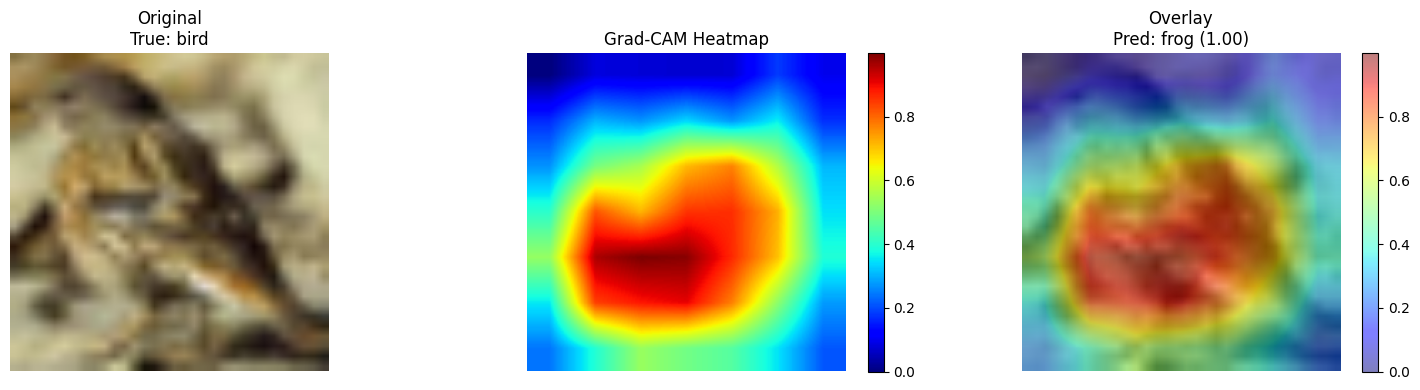

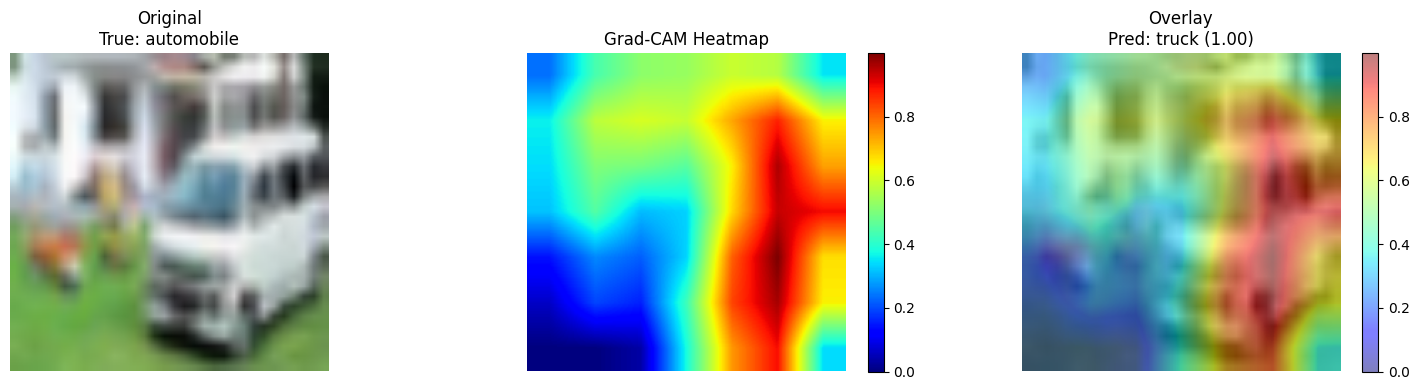

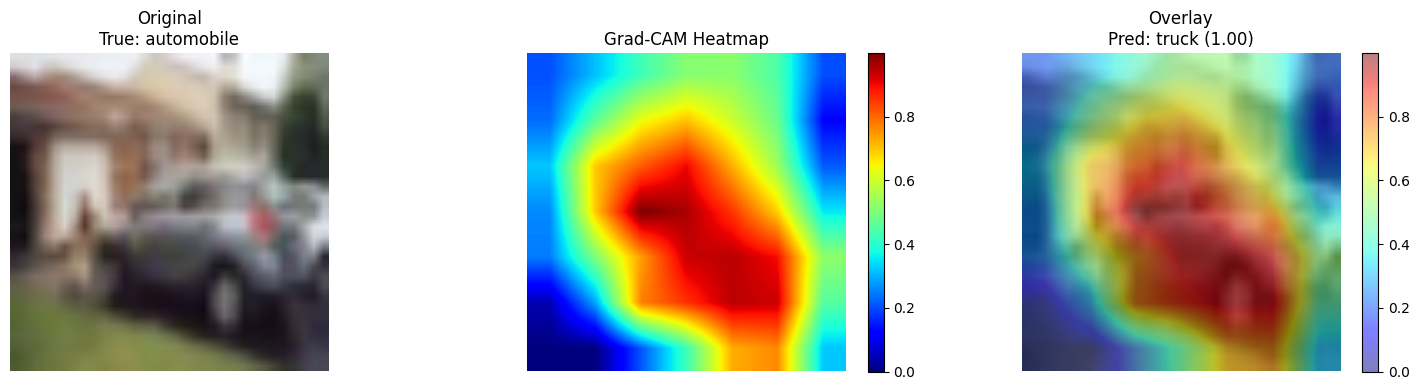

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

model.eval()

cam = GradCAM(
    model=model,
    target_layers=[model.layer4[-1]],
)

for i, case in enumerate(failure_cases[:5]):   

    input_tensor = case["image"].unsqueeze(0).float().to(device)
    targets = [ClassifierOutputTarget(case["pred"])]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    
    img = case["image"].permute(1, 2, 0).cpu().numpy()
    img = np.clip(img, 0, 1)

    true_class = class_names[case["true"]]
    pred_class = class_names[case["pred"]]

   
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    # 1️ Original image
    axs[0].imshow(img)
    axs[0].set_title(f"Original\nTrue: {true_class}")
    axs[0].axis("off")

    # 2️ Heatmap
    heatmap = axs[1].imshow(grayscale_cam, cmap='jet')
    axs[1].set_title("Grad-CAM Heatmap")
    axs[1].axis("off")
    fig.colorbar(heatmap, ax=axs[1], fraction=0.046)

    # 3️ Overlay
    axs[2].imshow(img)
    overlay = axs[2].imshow(grayscale_cam, cmap='jet', alpha=0.5)
    axs[2].set_title(
        f"Overlay\nPred: {pred_class} ({case['conf']:.2f})"
    )
    axs[2].axis("off")
    fig.colorbar(overlay, ax=axs[2], fraction=0.046)

    plt.tight_layout()
    plt.show()
